# ¿El trabajo remoto te deja solo?

**7 de cada 100** estadounidenses trabajaban desde casa en 2019. Para 2023 eran **28**. Se cuadruplicó en cuatro años.

Cuando la oficina desaparece, también desaparecen las horas que pasabas rodeado de gente sin darte cuenta. Cinco encuestas nacionales —**588.322 trabajadores**— siguieron la pista de qué le hizo eso a la cabeza.

:::{image} figuras/pixabot.png
:alt: Mascota Pixabot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** [Home alone: Remote work, isolation, and mental health](https://doi.org/10.1126/science.aec7671) · *Science* (2026)
**DOI:** [10.1126/science.aec7671](https://doi.org/10.1126/science.aec7671)

[![Abrir en Colab]( https://colab.research.google.com/assets/colab-badge.svg )](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-07-trabajo-remoto-soledad-mental/notebook.ipynb)

🎥 **Video:** [Ver en YouTube](https://youtube.com/shorts/OZa8Peu4YmA)

## Qué midieron, y por qué no es trivial

El trabajo remoto no se reparte al azar: quien programa puede irse a casa; quien atiende una caja, no. Así que no basta con mirar si la gente que trabaja desde casa está peor —podrían estarlo por mil razones distintas.

El equipo comparó dos grupos entre **2011 y 2024** (saltándose 2020-2021, los años duros de la pandemia): trabajos **remotables**, donde el trabajo desde casa se disparó tras el COVID, contra trabajos **no remotables**, donde apenas cambió. La diferencia entre lo que le pasó a cada grupo —el truco se llama *diferencias en diferencias*— aísla el efecto del trabajo remoto del de la pandemia en general.

No es un experimento con asignación al azar. Pero es lo más cerca que se puede llegar sin sortear quién se queda en casa.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SLUG = "2026-06-07-trabajo-remoto-soledad-mental"
MEDIDA = 'Distres K-6 (PSID)'   # prueba: 'Medicacion depresion/ansiedad', 'Toda medicacion de salud mental'
COLOR_DATOS      = '#2563EB'    # azul CaM — dato principal
COLOR_ALERTA     = '#DC2626'    # rojo — vive solo / lo que preocupa
COLOR_SECUNDARIO = '#059669'    # emerald — comparación
COLOR_REFERENCIA = '#D97706'    # amber — umbral / referencia
COLOR_GRIS       = '#BBBBBB'    # gris — agregado / contexto
FUENTE = 'Fuente: Home alone (Science, 2026) · DOI 10.1126/science.aec7671 | Datos transcritos del texto de acceso abierto'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Los CSV guardan etiquetas sin tilde; este mapa las muestra acentuadas
ETIQUETAS = {
    'Distres K-6': 'Distrés K-6',
    'Distres K-6 (PSID)': 'Distrés K-6 (PSID)',
    'Distres interfiere en la vida': 'Distrés que interfiere en la vida',
    'Dias deprimido al ano': 'Días deprimido al año',
    'Uso de atencion de salud mental': 'Uso de atención de salud mental',
    'Medicacion depresion/ansiedad': 'Medicación depresión/ansiedad',
    'Toda medicacion de salud mental': 'Toda medicación de salud mental',
}
def etiq(x): return ETIQUETAS.get(x, x)

def num(v, dec=1):  # decimales con coma (español)
    return f"{v:.{dec}f}".replace('.', ',')

# Estilo CaM: local (repo) → /tmp (container) → GitHub raw (Colab)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

DATOS = 'datos'
def cargar(nombre):
    p = f'{DATOS}/{nombre}'
    if not os.path.exists(p):                      # Colab: descargar
        os.makedirs(DATOS, exist_ok=True)
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{nombre}', p)
    return pd.read_csv(p)

cambio_remoto = cargar('cambio_remoto.csv')
jornada_solo  = cargar('jornada_solo.csv')
contacto      = cargar('contacto_social.csv')
salud         = cargar('salud_mental.csv')
amplif        = cargar('vive_solo_amplificacion.csv')
atribucion    = cargar('atribucion_nacional.csv')

print(f"Trabajadores en las 5 encuestas: 588.322")
print(f"Periodo: 2011-2024 (sin 2020-2021)")
rem = cambio_remoto.set_index('grupo')['remoto_2024_pct']
print(f"Jornadas 100% remotas en 2024 — remotables: {num(rem['Trabajos remotables'],1)}%  vs  no remotables: {num(rem['Trabajos no remotables'],1)}%")
print(f"Efecto del trabajo remoto (diferencias en diferencias): +{num(cambio_remoto.iloc[0]['did_pp'],1)} puntos porcentuales")

Trabajadores en las 5 encuestas: 588.322
Periodo: 2011-2024 (sin 2020-2021)
Jornadas 100% remotas en 2024 — remotables: 31,1%  vs  no remotables: 8,9%
Efecto del trabajo remoto (diferencias en diferencias): +17,9 puntos porcentuales


## Aquí está.

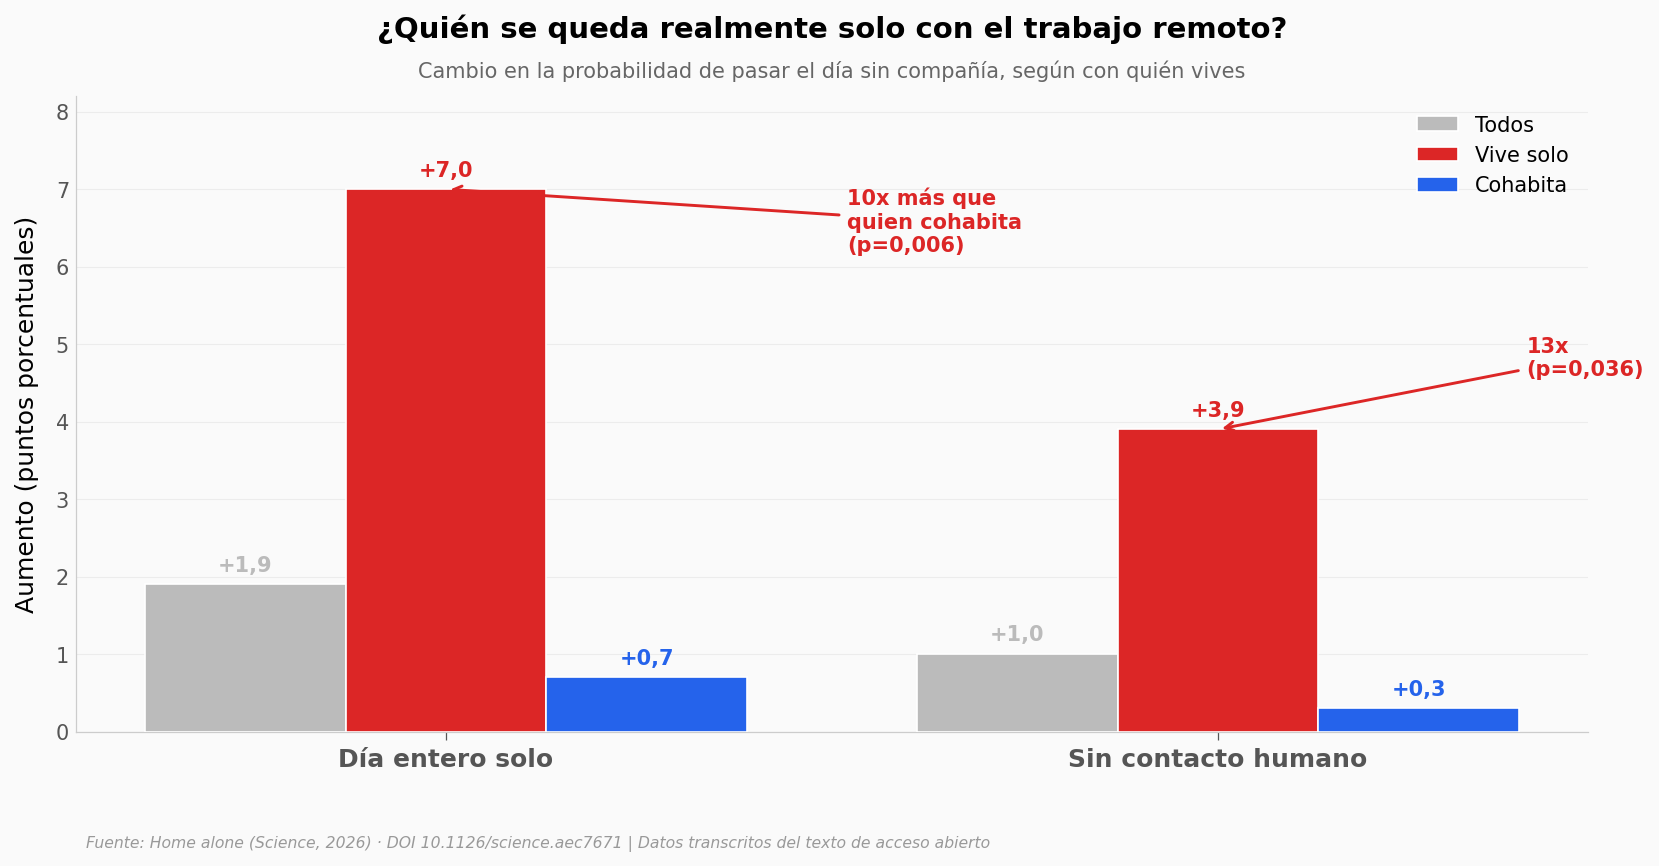

In [2]:
# Hero: el aislamiento no golpea a todos por igual
fig, ax = plt.subplots(figsize=(13, 5.5))

# Las etiquetas del CSV van sin tilde; se muestran con tilde
medidas_csv  = ['Dia entero solo', 'Sin contacto humano']
medidas_disp = ['Día entero solo', 'Sin contacto humano']
grupos  = ['Todos', 'Vive solo', 'Cohabita']
colores = {'Todos': COLOR_GRIS, 'Vive solo': COLOR_ALERTA, 'Cohabita': COLOR_DATOS}

piv = contacto.pivot_table(index='medida', columns='grupo', values='cambio_pp')
x = np.arange(len(medidas_csv))
ancho = 0.26
for i, g in enumerate(grupos):
    vals = [piv.loc[m, g] for m in medidas_csv]
    barras = ax.bar(x + (i-1)*ancho, vals, ancho, label=g, color=colores[g],
                    edgecolor='white', linewidth=0.8, zorder=3)
    for b, v in zip(barras, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.12, f'+{num(v,1)}', ha='center',
                va='bottom', fontsize=10, fontweight='bold', color=colores[g])

ax.set_xticks(x)
ax.set_xticklabels(medidas_disp, fontsize=12, fontweight='bold')
ax.set_ylabel('Aumento (puntos porcentuales)')
ax.set_ylim(0, 8.2)
ax.set_title('¿Quién se queda realmente solo con el trabajo remoto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cambio en la probabilidad de pasar el día sin compañía, según con quién vives',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

# Brechas vive-solo / cohabita (con el p del contraste entre grupos, del paper)
pdiff = contacto[contacto['grupo']=='Vive solo'].set_index('medida')['p_diff_vs_cohabita']
ax.annotate(f"10x más que\nquien cohabita\n(p={num(pdiff['Dia entero solo'],3)})",
            xy=(0-0.0, 7.0), xytext=(0.52, 6.2),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.4))
ax.annotate(f"13x\n(p={num(pdiff['Sin contacto humano'],3)})",
            xy=(1+0.0, 3.9), xytext=(1.40, 4.6),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.4))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_aislamiento.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que salta a la vista: quien vive solo suma **7 puntos porcentuales** de días enteros sin compañía — diez veces lo de quien vive acompañado (0,7). En los días sin *ningún* contacto humano, la brecha se abre hasta trece veces (3,9 contra 0,3).

El trabajo remoto no aísla a todos por igual. Para quien vive con alguien, casi no cambia nada: en casa sigue habiendo otra persona. Para quien vive solo, la oficina era el lugar donde había gente. Y ese lugar desapareció.

La diferencia entre vivir solo y cohabitar es estadísticamente sólida: el paper la prueba directamente con un contraste entre grupos (p=0,006 para los días enteros solo; p=0,036 para los días sin contacto).

## Pero espera, ¿de verdad cambió tanto?

Antes de meternos con la salud mental, pongamos números sobre la mesa.

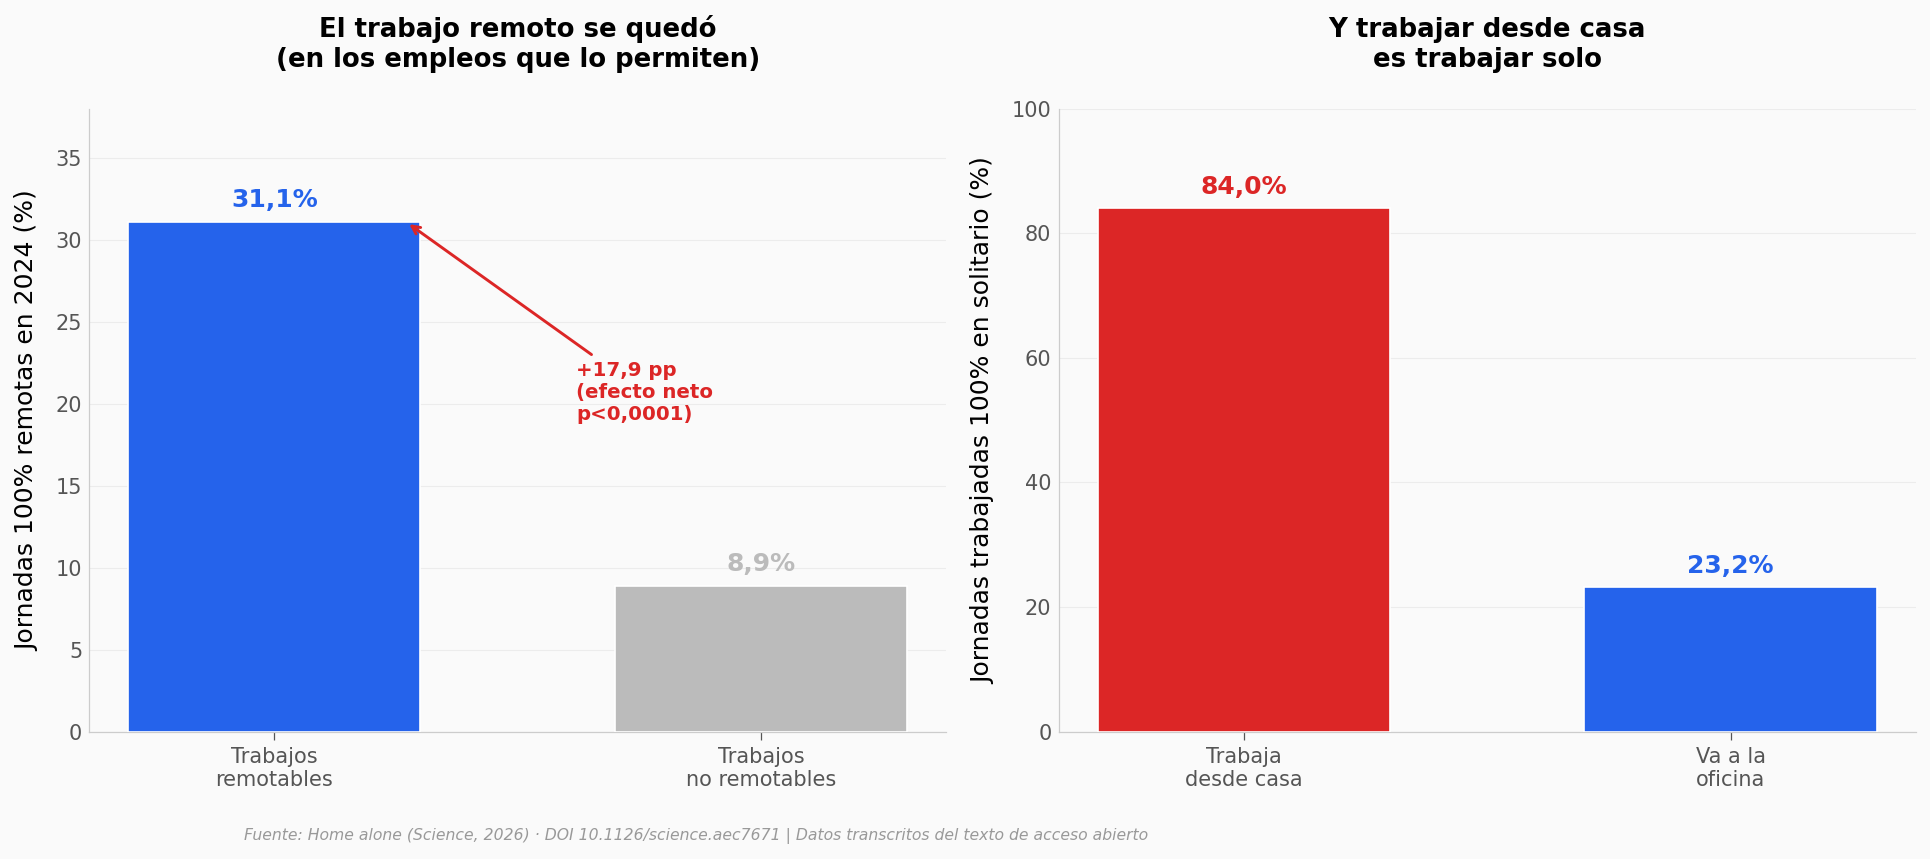

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel izquierdo: el salto del trabajo remoto (DiD)
g = cambio_remoto.set_index('grupo')['remoto_2024_pct']
labels1 = ['Trabajos\nremotables', 'Trabajos\nno remotables']
vals1 = [g['Trabajos remotables'], g['Trabajos no remotables']]
cols1 = [COLOR_DATOS, COLOR_GRIS]
b1 = ax1.bar(labels1, vals1, color=cols1, width=0.6, edgecolor='white', linewidth=0.8, zorder=3)
for b, v in zip(b1, vals1):
    ax1.text(b.get_x()+b.get_width()/2, v+0.6, f'{num(v,1)}%', ha='center', va='bottom',
             fontsize=12, fontweight='bold', color=b.get_facecolor())
ax1.set_ylim(0, 38)
ax1.set_ylabel('Jornadas 100% remotas en 2024 (%)')
ax1.set_title('El trabajo remoto se quedó\n(en los empleos que lo permiten)', fontsize=12.5, fontweight='bold', pad=20)
ax1.annotate('+17,9 pp\n(efecto neto\np<0,0001)', xy=(0.27, 31.1), xytext=(0.62, 19),
             fontsize=9.5, fontweight='bold', color=COLOR_ALERTA, ha='left',
             arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.4))

# Panel derecho: la jornada en solitario
j = jornada_solo.set_index('lugar')['pct_jornada_entera_solo']
labels2 = ['Trabaja\ndesde casa', 'Va a la\noficina']
vals2 = [j['Trabaja desde casa'], j['Va a la oficina']]
cols2 = [COLOR_ALERTA, COLOR_DATOS]
b2 = ax2.bar(labels2, vals2, color=cols2, width=0.6, edgecolor='white', linewidth=0.8, zorder=3)
for b, v in zip(b2, vals2):
    ax2.text(b.get_x()+b.get_width()/2, v+1.5, f'{num(v,1)}%', ha='center', va='bottom',
             fontsize=12, fontweight='bold', color=b.get_facecolor())
ax2.set_ylim(0, 100)
ax2.set_ylabel('Jornadas trabajadas 100% en solitario (%)')
ax2.set_title('Y trabajar desde casa\nes trabajar solo', fontsize=12.5, fontweight='bold', pad=20)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/remoto_y_jornada.png', dpi=200, bbox_inches='tight')
plt.show()

## Más horas solo. ¿Y la cabeza?

Pasar más tiempo sin nadie tiene que dejar marca en algún lado. El equipo lo rastreó en varias señales independientes de salud mental, cada una de una encuesta distinta. No es un solo número: es el mismo patrón apareciendo en sitios separados.

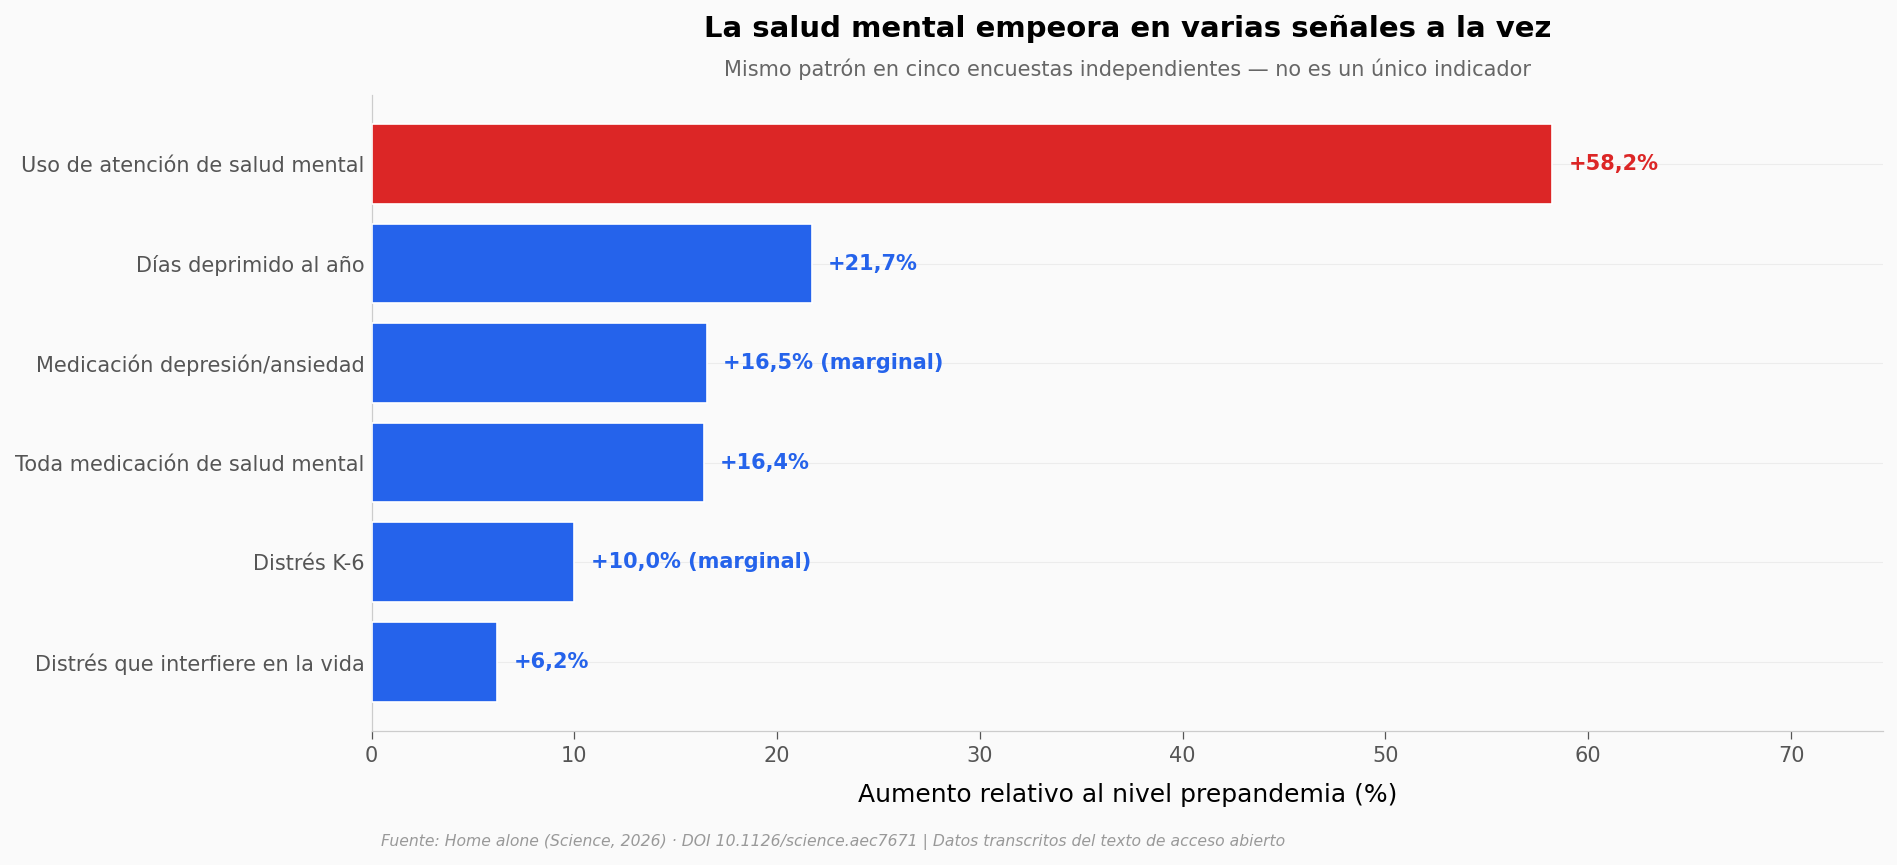

In [4]:
# Salud mental: aumento relativo al nivel prepandemia
# El paper reporta varias señales como '% de cambio respecto a la media prepandemia'.
# Para las que vienen en valor absoluto + media, calculamos ese % de forma transparente.
s = salud.copy()
def pct_aumento(r):
    if pd.notna(r['cambio_pct']):
        return r['cambio_pct']
    if pd.notna(r['cambio']) and pd.notna(r['media_prepandemia']) and r['media_prepandemia'] > 0:
        return 100 * r['cambio'] / r['media_prepandemia']
    return np.nan
s['pct'] = s.apply(pct_aumento, axis=1)
s = s.dropna(subset=['pct']).drop_duplicates(subset=['medida']).sort_values('pct')

fig, ax = plt.subplots(figsize=(13, 5.5))
# El uso de servicios es el salto más grande → rojo; el resto azul
cols = [COLOR_ALERTA if v == s['pct'].max() else COLOR_DATOS for v in s['pct']]
barras = ax.barh([etiq(m) for m in s['medida']], s['pct'], color=cols, edgecolor='white', linewidth=0.8, zorder=3)
for b, (_, r) in zip(barras, s.iterrows()):
    p = r['p_value']
    marca = ' (marginal)' if pd.notna(p) and p > 0.05 else ''
    ax.text(r['pct']+0.8, b.get_y()+b.get_height()/2, f"+{num(r['pct'],1)}%{marca}",
            va='center', fontsize=10, fontweight='bold', color=b.get_facecolor())
ax.set_xlim(0, s['pct'].max()*1.28)
ax.set_xlabel('Aumento relativo al nivel prepandemia (%)')
ax.set_title('La salud mental empeora en varias señales a la vez',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mismo patrón en cinco encuestas independientes — no es un único indicador',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/salud_mental.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que cabe en la cuenta

Dos preguntas cierran la historia. Primero: si el daño se concentra en quien vive solo, **¿cuánto más fuerte** golpea ahí? Y segundo, la grande: de todo el aumento de soledad y malestar mental que vivió el país en esta década, **¿cuánto es culpa del trabajo remoto?**

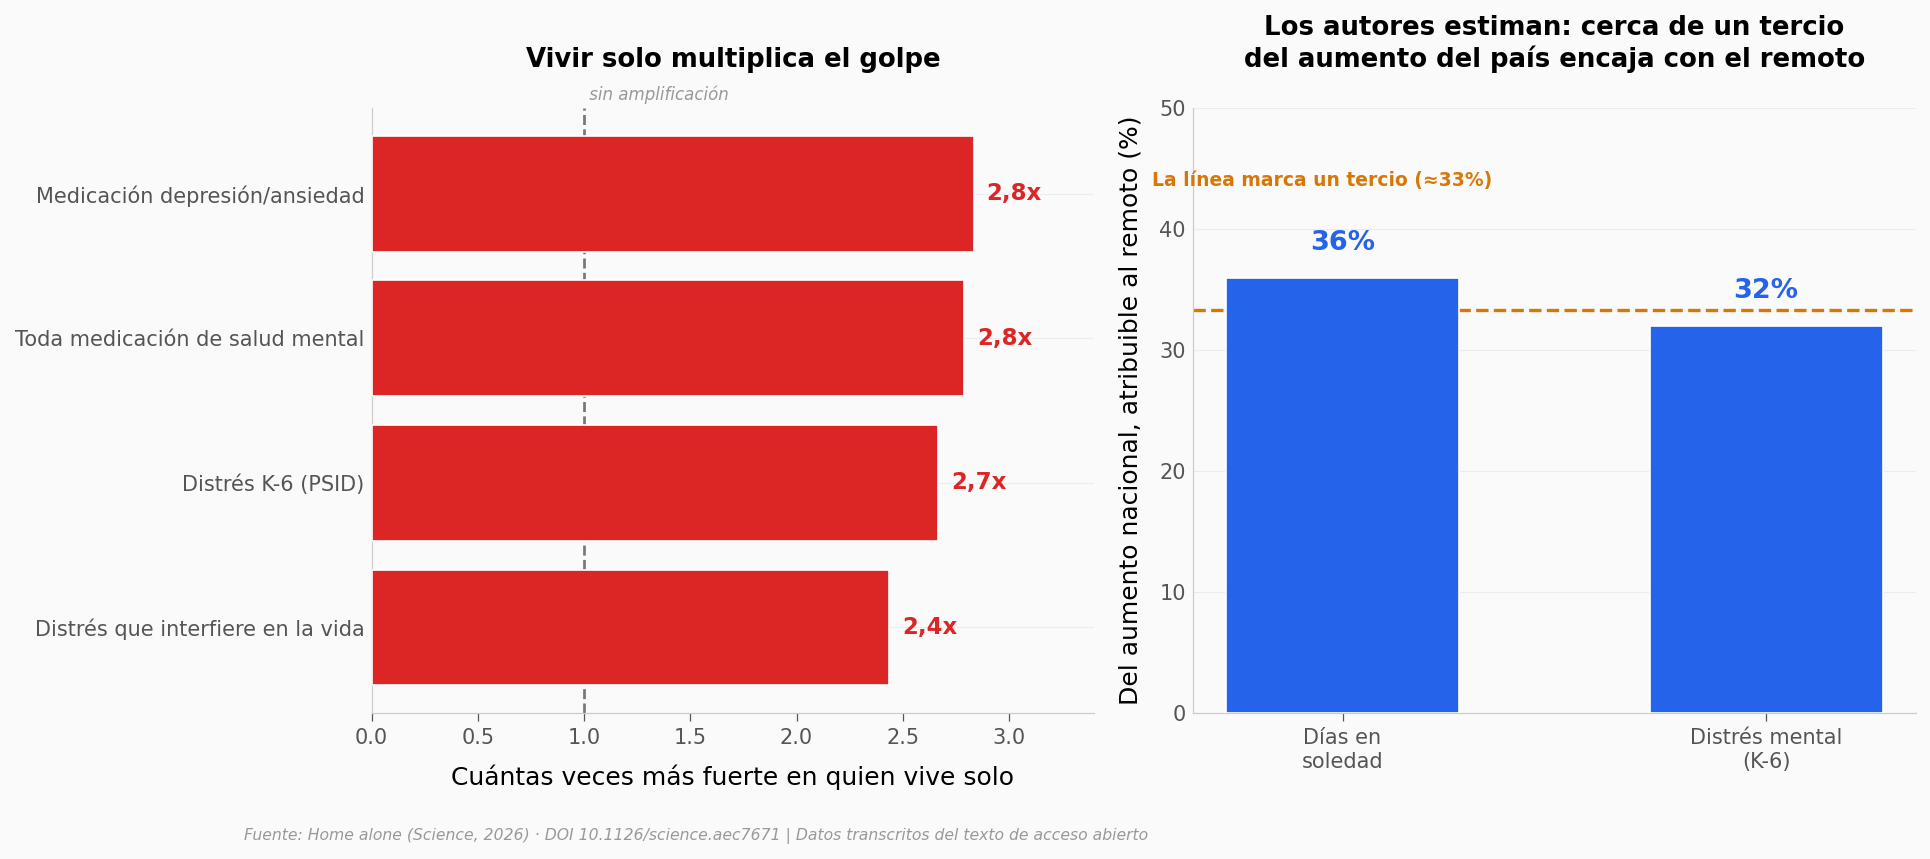

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel izquierdo: cuánto amplifica vivir solo (razón vive_solo / agregado)
a = amplif.copy()
a['razon'] = a['vive_solo'] / a['agregado']
a = a.sort_values('razon')
b1 = ax1.barh([etiq(m) for m in a['medida']], a['razon'], color=COLOR_ALERTA, edgecolor='white',
              linewidth=0.8, zorder=3)
for b, (_, r) in zip(b1, a.iterrows()):
    ax1.text(r['razon']+0.06, b.get_y()+b.get_height()/2,
             f"{num(r['razon'],1)}x", va='center', fontsize=11, fontweight='bold', color=COLOR_ALERTA)
ax1.axvline(1.0, color='#777777', linewidth=1.3, linestyle='--', zorder=2)
ax1.text(1.0, len(a)-0.35, ' sin amplificación', fontsize=8, color='#999999', ha='left', style='italic')
ax1.set_xlim(0, 3.4)
ax1.set_xlabel('Cuántas veces más fuerte en quien vive solo')
ax1.set_title('Vivir solo multiplica el golpe', fontsize=12.5, fontweight='bold', pad=20)

# Panel derecho: atribución nacional (~1/3)
at = atribucion.copy()
labels = ['Días en\nsoledad', 'Distrés mental\n(K-6)']
vals = at['atribuible_remoto_pct'].tolist()
b2 = ax2.bar(labels, vals, color=COLOR_DATOS, width=0.55, edgecolor='white', linewidth=0.8, zorder=3)
for b, v in zip(b2, vals):
    ax2.text(b.get_x()+b.get_width()/2, v+1.8, f'{v:.0f}%', ha='center', va='bottom',
             fontsize=13, fontweight='bold', color=COLOR_DATOS)
ax2.axhline(33.3, color=COLOR_REFERENCIA, linewidth=1.6, linestyle='--', zorder=2)
ax2.text(-0.45, 44, 'La línea marca un tercio (≈33%)', fontsize=9, fontweight='bold',
         color=COLOR_REFERENCIA, va='center', ha='left')
ax2.set_ylim(0, 50)
ax2.set_ylabel('Del aumento nacional, atribuible al remoto (%)')
ax2.set_title('Los autores estiman: cerca de un tercio\ndel aumento del país encaja con el remoto', fontsize=12.5, fontweight='bold', pad=20)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/amplificacion_atribucion.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El trabajo remoto subió **+17,9 pp** más en trabajos remotables que en no remotables | ✅ | Diferencia medida directamente (diferencias en diferencias), p<0,0001. Es el dato más sólido. |
| Quien trabaja remoto pasa **más tiempo solo**: +1,1 h despierto, +1,2 h trabajando (+58%) | ✅ | Diferencial medido, p<0,0001. |
| El aislamiento **se concentra en quien vive solo** (10x en días solo, 13x sin contacto) | ✅ | El paper prueba la diferencia vive-solo vs cohabita con un contraste directo (p=0,006 y p=0,036); el aumento agregado también es significativo (p=0,013 y p=0,035). |
| La **salud mental empeora** en varias señales (uso de servicios +58%, días deprimido +21,7%) | ⚠️ | Sólido en uso de servicios y días deprimido; el distrés K-6 (PSID, p=0,063) y la medicación (p=0,066) quedan en el margen de la significancia. |
| El trabajo remoto explica **~1/3** del aumento nacional de soledad y distrés | ⚠️ | Es una *estimación* del paper (36% soledad, 32% distrés), válida bajo los supuestos del diseño. No es una medición directa. |
| Esto **prueba** que el trabajo remoto causa daño mental | ❌ | Es cuasi-experimental, no aleatorizado. Los datos apuntan fuerte en esa dirección, pero la causalidad se sostiene en supuestos (tendencias paralelas), no en un sorteo. |

> **Limitaciones:** diseño observacional/diferencias en diferencias (nadie fue asignado al azar a trabajar remoto); los valores graficados se transcribieron del texto de acceso abierto porque el dataset Dryad estaba en curación al momento de extraer; el índice K-6 mide *riesgo* de distrés, no un diagnóstico clínico; el resultado depende del supuesto de tendencias paralelas entre los dos grupos. A favor de la lectura causal: los controles placebo (exámenes físicos, estatinas) **no** se movieron, lo que descarta que sea solo "más tiempo libre para ir al médico".

## Ahora tú

1. **¿El daño es solo de quien vive solo?** Cambia `MEDIDA` en la celda de configuración y compara, en `amplif`, la columna `vive_solo` contra `agregado`. ¿Hay alguna señal donde vivir acompañado *no* proteja?
   ```python
   amplif[amplif['medida'].str.contains('Medicacion')]
   ```

2. **¿Qué señal crece más rápido?** Ordena la salud mental por el aumento relativo. ¿Gana el uso de servicios o los días deprimido?
   ```python
   salud.assign(pct=salud['cambio_pct']).dropna(subset=['pct']).sort_values('pct', ascending=False)
   ```

3. **¿Cuadra la "dosis"?** El trabajo remoto subió 17,9 pp y los días enteros solo subieron 1,9 pp en promedio. Divide uno por otro: ¿cuánto aislamiento extra trae cada punto de trabajo remoto?
   ```python
   1.9 / 17.9
   ```

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto amplifica vivir solo una señal concreta? Cambia MEDIDA arriba.
fila = amplif[amplif['medida'].str.contains(MEDIDA.split('(')[0].strip(), case=False)]
if len(fila):
    r = fila.iloc[0]
    razon = r['vive_solo'] / r['agregado']
    print(f"Señal: {etiq(r['medida'])}")
    print(f"  Efecto en el agregado : {r['agregado']} {r['unidad']}")
    print(f"  Efecto en quien vive solo: {r['vive_solo']} {r['unidad']}  (p={r['p_vive_solo']})")
    print(f"  → Vivir solo lo multiplica por {razon:.1f}x")
else:
    print(f"No encontré '{MEDIDA}' en la tabla de amplificación.")
    print("Opciones:", ', '.join(amplif['medida'].tolist()))

Señal: Distrés K-6 (PSID)
  Efecto en el agregado : 0.3 unidades
  Efecto en quien vive solo: 0.8 unidades  (p=0.003)
  → Vivir solo lo multiplica por 2.7x


## Fuentes

**Paper**: [Home alone: Remote work, isolation, and mental health](https://doi.org/10.1126/science.aec7671)  
*Science, 2026-06-04*

**Dataset canónico**: [Data for: Home alone: Remote work, isolation, and mental health](https://doi.org/10.5061/dryad.w3r22816p)  
*Dryad — en curación al extraer; valores transcritos del texto de acceso abierto*

*21 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [repositorio del Lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-06-07-trabajo-remoto-soledad-mental). Licencia de datos según la fuente original.*